In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["font.size"] = 14
pd.options.display.float_format = "{:.3f}".format

In [3]:
def load_table(table_path):
    df = pd.read_csv(table_path, sep="|")
    df = df.rename(columns={c: c.strip() for c in df.columns})
    circuit_names = df[""].str.replace("result_SELECT_", "")
    df = df.drop(columns=[""])
    df = df.astype(float)
    return circuit_names, df

# 性能比較

In [4]:
circuit_names, code_beat_df = load_table(
    "../../out/table/table_select_10_20250421_0112.txt"
)

In [5]:
circuit_names

0       10_FermiHubbard2D_cylinder_0_0_0.in 
1       10_FermiHubbard2D_cylinder_0_0_1.in 
2       10_FermiHubbard2D_cylinder_0_0_2.in 
3       10_FermiHubbard2D_cylinder_0_0_3.in 
4       10_FermiHubbard2D_cylinder_0_0_4.in 
5              10_Heisenberg1D_OBC_1_0_0.in 
6              10_Heisenberg1D_OBC_1_0_1.in 
7              10_Heisenberg1D_OBC_1_0_2.in 
8              10_Heisenberg1D_OBC_1_0_3.in 
9              10_Heisenberg1D_OBC_1_0_4.in 
10             10_Heisenberg1D_OBC_1_0_5.in 
11    10_Heisenberg2D_cylinder_0.5_0.5_0.in 
12    10_Heisenberg2D_cylinder_0.5_0.5_1.in 
13    10_Heisenberg2D_cylinder_0.5_0.5_2.in 
14    10_Heisenberg2D_cylinder_0.5_0.5_3.in 
15    10_Heisenberg2D_cylinder_0.5_0.5_4.in 
16    10_Heisenberg2D_cylinder_0.5_0.5_5.in 
17    10_Heisenberg2D_cylinder_0.5_0.5_6.in 
18      10_Heisenberg2D_cylinder_1_0.5_0.in 
19      10_Heisenberg2D_cylinder_1_0.5_1.in 
20      10_Heisenberg2D_cylinder_1_0.5_2.in 
21      10_Heisenberg2D_cylinder_1_0.5_3.in 
22      10

In [6]:
code_beat_df

,Single No Top (1 outer random),Single No Kink (1 outer random),Proj No Top (1 outer random),Proj No Kink (1 outer random),Proj Yes Kink (1 outer random),Double No Top (1 outer random),Double No Kink (1 outer random),Double Yes Kink (1 outer random),Single No Top (1 outer SA),Single No Kink (1 outer SA),...,Double Yes Kink (2 outer SA),Single No Top (2 outer naive),Single No Kink (2 outer naive),Single Yes Kink (2 outer naive),Proj No Top (2 outer naive),Proj No Kink (2 outer naive),Proj Yes Kink (2 outer naive),Double No Top (2 outer naive),Double No Kink (2 outer naive),Double Yes Kink (2 outer naive)
0,14876.000,14876.000,14040.000,14041.000,14040.000,14538.000,14538.000,14542.000,14876.000,14876.000,...,14541.000,14876.000,14876.000,14876.000,14040.000,14044.000,14044.000,14538.000,14539.000,14541.000
1,8922.000,8929.000,8526.000,8817.000,8863.000,8778.000,8866.000,8876.000,8922.000,8925.000,...,8794.000,8922.000,8922.000,8923.000,8526.000,9514.000,9515.000,8778.000,8780.000,8794.000
2,4940.000,4941.000,4442.000,4719.000,4732.000,4870.000,5202.000,5186.000,4940.000,4941.000,...,4886.000,4940.000,4940.000,4940.000,4442.000,5677.000,5687.000,4869.000,4877.000,4892.000
3,2640.000,2698.000,2318.000,2586.000,2612.000,2595.000,2644.000,2641.000,2640.000,2682.000,...,2612.000,2640.000,2648.000,2650.000,2318.000,3180.000,3172.000,2595.000,2702.000,2721.000
4,1538.000,1652.000,1178.000,1491.000,1495.000,1506.000,1535.000,1548.000,1539.000,1588.000,...,1616.000,1539.000,1600.000,1625.000,1178.000,1738.000,1754.000,1507.000,1573.000,1590.000
5,810.000,810.000,648.000,657.000,658.000,752.000,752.000,756.000,810.000,810.000,...,752.000,810.000,810.000,810.000,648.000,650.000,650.000,752.000,753.000,753.000
6,421.000,424.000,324.000,331.000,331.000,389.000,398.000,400.000,421.000,421.000,...,390.000,421.000,421.000,421.000,324.000,333.000,335.000,389.000,390.000,391.000
7,228.000,240.000,165.000,187.000,189.000,210.000,243.000,246.000,228.000,229.000,...,226.000,228.000,230.000,234.000,165.000,183.000,184.000,209.000,218.000,221.000
8,136.000,152.000,84.000,109.000,111.000,121.000,144.000,147.000,137.000,143.000,...,140.000,137.000,168.000,162.000,84.000,144.000,148.000,121.000,162.000,156.000
9,98.000,153.000,63.000,99.000,103.000,79.000,123.000,126.000,98.000,113.000,...,113.000,92.000,124.000,129.000,45.000,122.000,127.000,78.000,118.000,125.000


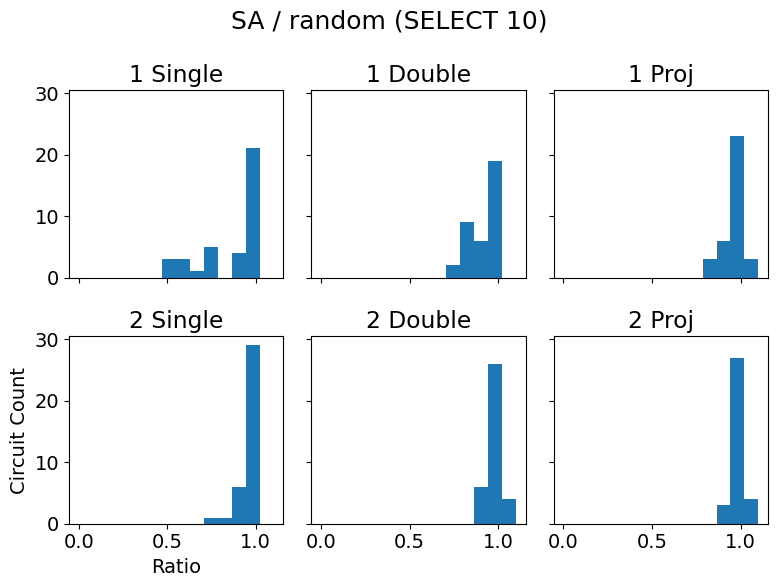

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(8, 6), sharex=True, sharey=True)
for i in range(2):
    layer_count = i + 1
    for j, method in enumerate(["Single", "Double", "Proj"]):
        rate = (
            code_beat_df[f"{method} No Kink ({layer_count} outer SA)"]
            / code_beat_df[f"{method} No Kink ({layer_count} outer random)"]
        )
        ax = axes[i, j]
        ax.hist(rate, bins=np.linspace(0, 1.1, 15))
        ax.set_title(f"{layer_count} {method}")

axes[1, 0].set_xlabel("Ratio")
axes[1, 0].set_ylabel("Circuit Count")
fig.suptitle("SA / random (SELECT 10)", fontsize=18)
plt.tight_layout()
plt.show()

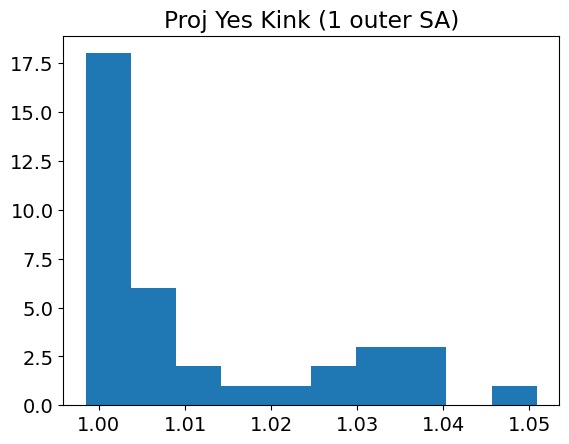

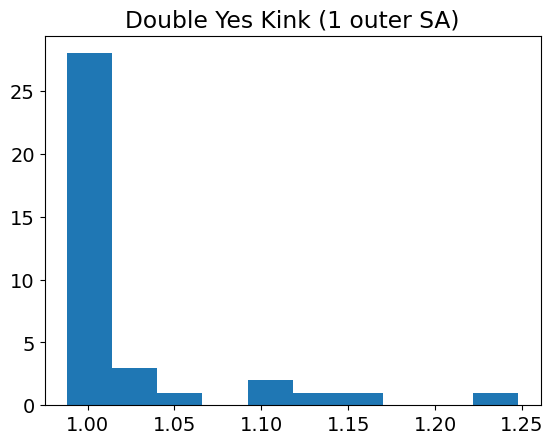

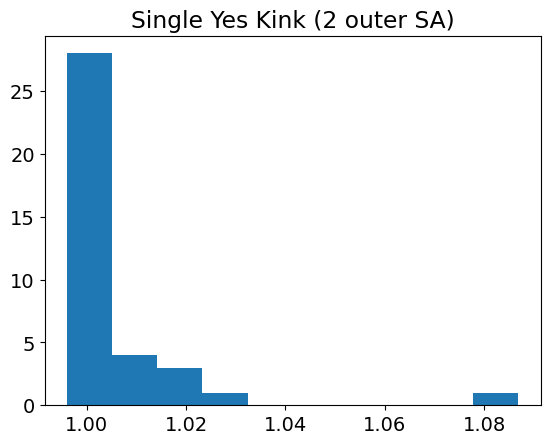

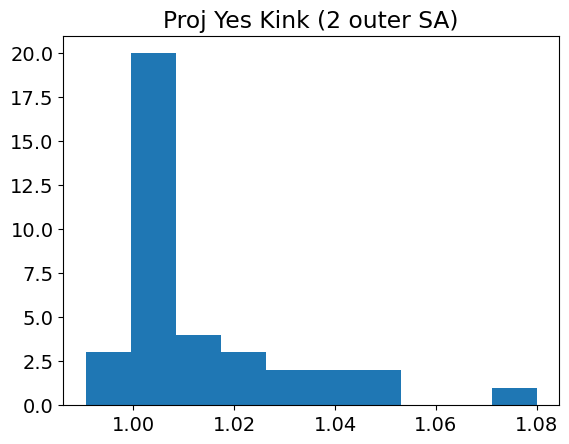

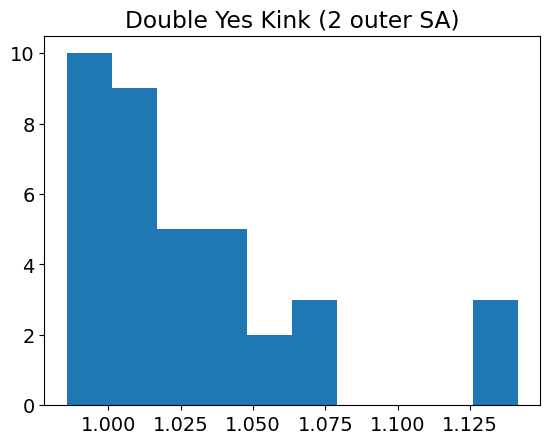

In [8]:
# Kink overhead
for yes_kink_sa_col in code_beat_df.columns:
    if "SA" in yes_kink_sa_col and "Yes" in yes_kink_sa_col:
        no_kink_sa_col = yes_kink_sa_col.replace("Yes", "No")
        ratio = code_beat_df[yes_kink_sa_col] / code_beat_df[no_kink_sa_col]
        fig, ax = plt.subplots()
        ax.hist(ratio)
        plt.title(yes_kink_sa_col)

In [9]:
rate = code_beat_df.div(code_beat_df["Single No Kink (1 outer SA)"], axis=0).mean()
rate[rate.index.str.contains("SA")].sort_values()

Proj No Top (2 outer SA)       0.708
Proj No Top (1 outer SA)       0.750
Proj No Kink (2 outer SA)      0.781
Proj Yes Kink (2 outer SA)     0.789
Proj No Kink (1 outer SA)      0.830
Proj Yes Kink (1 outer SA)     0.839
Double No Top (2 outer SA)     0.863
Double No Top (1 outer SA)     0.884
Double No Kink (2 outer SA)    0.925
Single No Top (2 outer SA)     0.943
Double No Kink (1 outer SA)    0.947
Single No Kink (2 outer SA)    0.948
Double Yes Kink (2 outer SA)   0.951
Single Yes Kink (2 outer SA)   0.952
Single No Top (1 outer SA)     0.961
Double Yes Kink (1 outer SA)   0.974
Single No Kink (1 outer SA)    1.000
dtype: float64

## optimal との比較

In [10]:
approx_rate = code_beat_df.div(code_beat_df["Proj No Top (2 outer SA)"], axis=0)
rate = approx_rate.mean()
rate[rate.index.str.contains("SA")].sort_values()

Proj No Top (2 outer SA)       1.000
Proj No Top (1 outer SA)       1.097
Proj No Kink (2 outer SA)      1.133
Proj Yes Kink (2 outer SA)     1.150
Proj No Kink (1 outer SA)      1.236
Proj Yes Kink (1 outer SA)     1.254
Double No Top (2 outer SA)     1.263
Double No Top (1 outer SA)     1.310
Double No Kink (2 outer SA)    1.384
Single No Top (2 outer SA)     1.398
Single No Kink (2 outer SA)    1.409
Single Yes Kink (2 outer SA)   1.419
Double Yes Kink (2 outer SA)   1.430
Double No Kink (1 outer SA)    1.433
Single No Top (1 outer SA)     1.441
Double Yes Kink (1 outer SA)   1.476
Single No Kink (1 outer SA)    1.523
dtype: float64

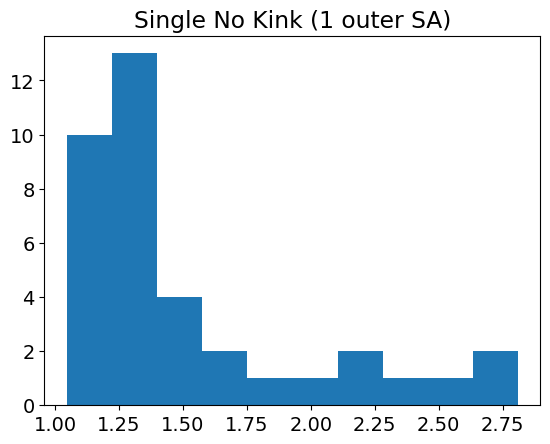

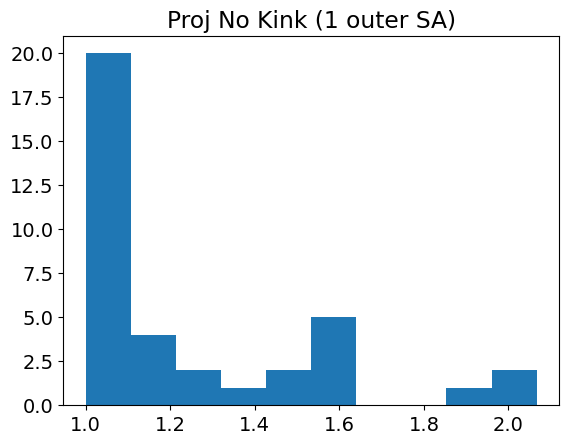

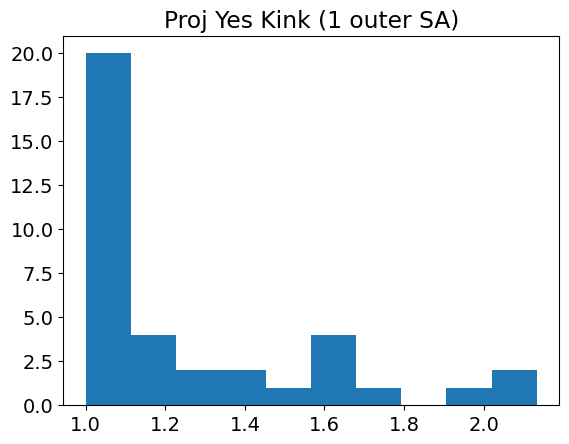

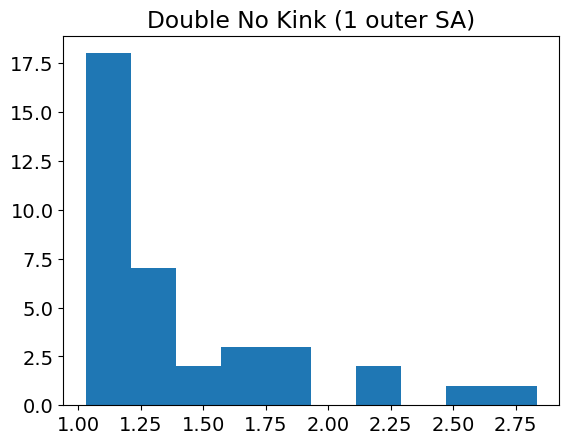

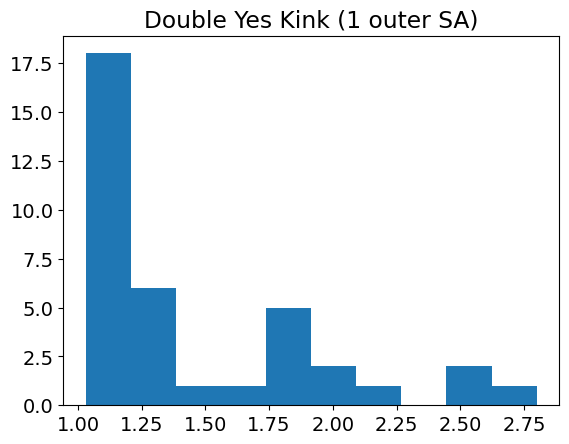

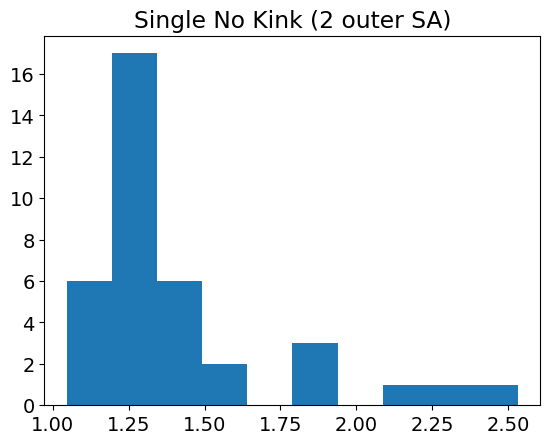

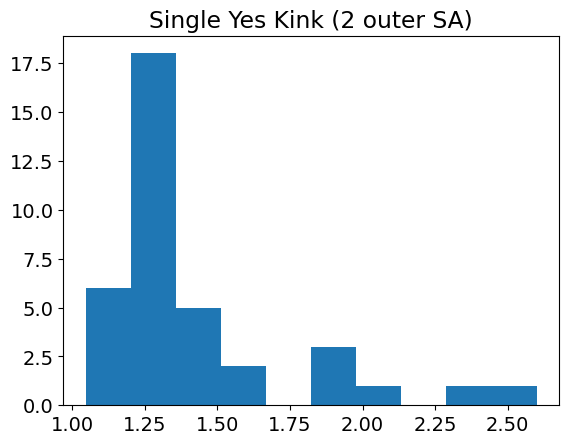

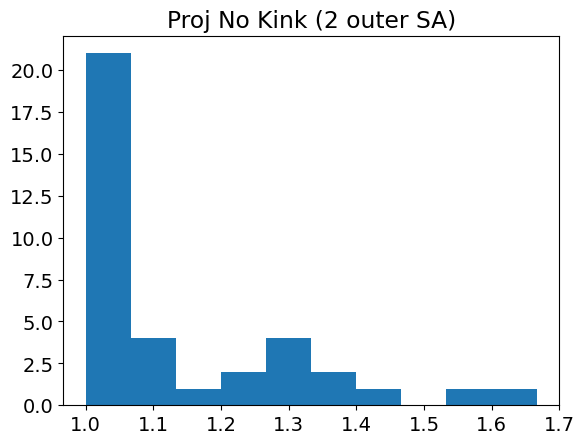

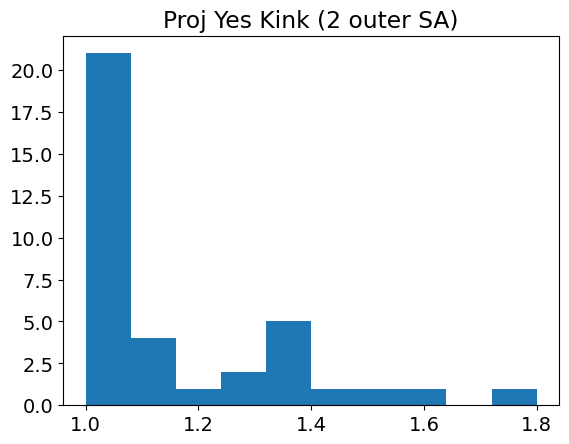

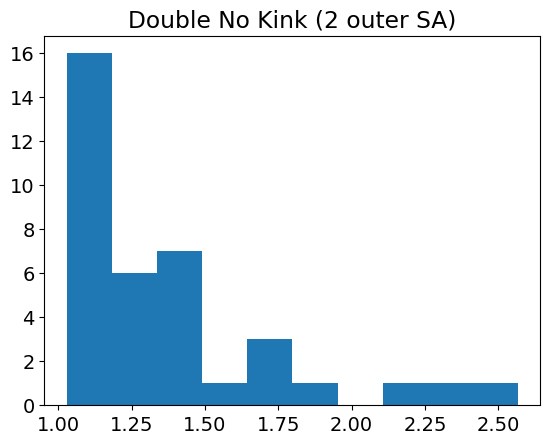

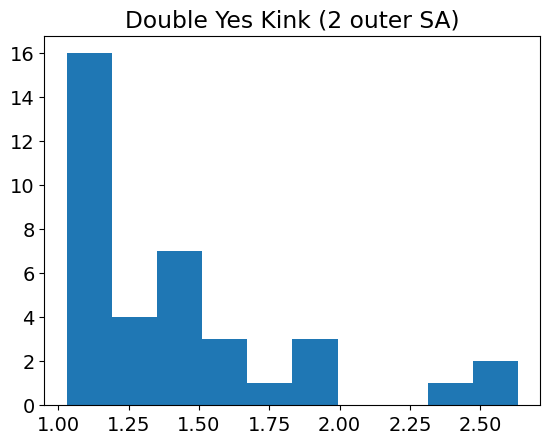

In [11]:
for name in approx_rate.columns:
    if "SA" in name and "No Top" not in name:
        fig, ax = plt.subplots()
        ax.set_title(name)
        ax.hist(approx_rate[name])

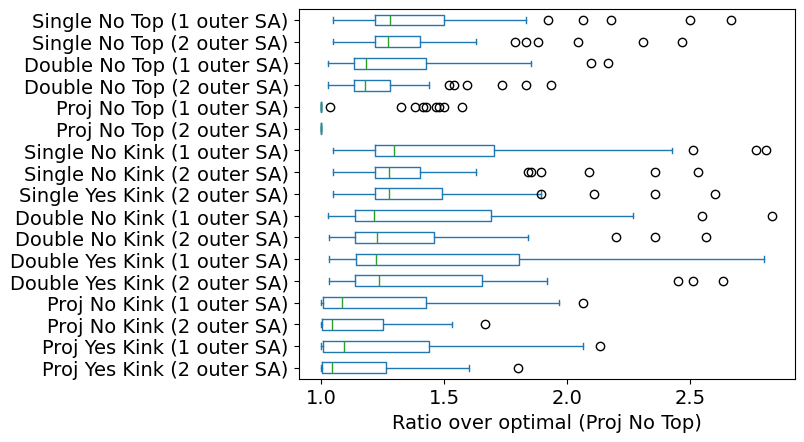

In [12]:
columns = [
    "Single No Top (1 outer SA)",
    "Single No Top (2 outer SA)",
    "Double No Top (1 outer SA)",
    "Double No Top (2 outer SA)",
    "Proj No Top (1 outer SA)",
    "Proj No Top (2 outer SA)",
    "Single No Kink (1 outer SA)",
    "Single No Kink (2 outer SA)",
    "Single Yes Kink (2 outer SA)",
    "Double No Kink (1 outer SA)",
    "Double No Kink (2 outer SA)",
    "Double Yes Kink (1 outer SA)",
    "Double Yes Kink (2 outer SA)",
    "Proj No Kink (1 outer SA)",
    "Proj No Kink (2 outer SA)",
    "Proj Yes Kink (1 outer SA)",
    "Proj Yes Kink (2 outer SA)",
]

# columns = [
#     "Double Yes Kink w/ skip (1 outer SA)",
#     "Double Yes Kink w/ skip (2 outer SA)",
#     "Double Yes Kink (1 outer SA)",
#     "Double Yes Kink (2 outer SA)",
#     "Double Yes Kink two cells (1 outer SA)",
#     "Double Yes Kink two cells (2 outer SA)",
#     "Double No Kink (1 outer SA)",
#     "Double No Kink (2 outer SA)",
#     "Double No Top (1 outer SA)",
# ]

rate = approx_rate.loc[:, columns]
rate.plot.box(vert=False)
plt.gca().invert_yaxis()
plt.xlabel("Ratio over optimal (Proj No Top)")
plt.show()

In [13]:
# 一番難しそうな回路
code_beat_df.iloc[10].sort_values()

Proj No Top (2 outer random)        24.000
Proj No Top (2 outer SA)            42.000
Proj No Top (2 outer naive)         42.000
Proj Yes Kink (2 outer random)      59.000
Proj No Kink (2 outer random)       60.000
Proj No Kink (2 outer SA)           60.000
Proj Yes Kink (2 outer SA)          63.000
Proj No Top (1 outer random)        66.000
Proj No Top (1 outer naive)         66.000
Proj No Top (1 outer SA)            66.000
Double No Top (2 outer random)      72.000
Double No Top (2 outer SA)          77.000
Double No Top (2 outer naive)       77.000
Proj No Kink (1 outer SA)           81.000
Proj Yes Kink (1 outer SA)          84.000
Double No Top (1 outer SA)          88.000
Double No Top (1 outer naive)       88.000
Double No Top (1 outer random)      88.000
Single No Top (2 outer random)      90.000
Proj No Kink (1 outer random)       95.000
Proj Yes Kink (1 outer random)      96.000
Single No Top (2 outer naive)       97.000
Single No Top (2 outer SA)          97.000
Double No K

# Fermi 実行時間

In [14]:
table_path = "../../out/table/select_4_Fermi_time_20250121.txt"

In [15]:
fermi_circuit_names, fermi_df = load_table(table_path)

In [16]:
fermi_circuit_names

0    4_FermiHubbard2D_cylinder_0_0_0.in 
1    4_FermiHubbard2D_cylinder_0_0_1.in 
2    4_FermiHubbard2D_cylinder_0_0_2.in 
3    4_FermiHubbard2D_cylinder_0_0_3.in 
4    4_FermiHubbard2D_cylinder_0_0_4.in 
Name: , dtype: object

In [17]:
fermi_df

,Single No Top (2D RND),Single No Kink (2D RND),Proj No Top (2D RND),Proj No Kink (2D RND),Double No Top (2D RND),Double No Kink (2D RND),Double Yes Kink (2D RND),Double Yes Kink w/ skip (2D RND),Single No Top (2D SA),Single No Kink (2D SA),...,Double Yes Kink w/ skip (2.5D RND),Single No Top (2.5D SA),Single No Kink (2.5D SA),Single Yes Kink (2.5D SA),Proj No Top (2.5D SA),Proj No Kink (2.5D SA),Double No Top (2.5D SA),Double No Kink (2.5D SA),Double Yes Kink (2.5D SA),Double Yes Kink w/ skip (2.5D SA)
0,0.757,2.670,0.215,9.564,0.588,4.000,4.878,4.811,0.703,2.523,...,8.743,0.722,2.946,20.523,0.245,12.009,0.612,3.375,4.081,4.418
1,0.921,4.746,0.245,13.159,0.621,7.560,8.887,8.996,0.635,3.789,...,10.116,0.655,4.814,33.258,0.224,14.600,0.573,3.536,4.227,4.250
2,0.799,8.032,0.243,19.970,0.641,11.702,13.907,14.145,0.706,6.290,...,18.156,0.736,6.825,46.401,0.240,20.868,0.620,4.032,4.844,4.951
3,0.879,15.315,0.281,35.629,0.784,23.391,29.781,29.564,0.883,13.130,...,32.856,0.893,13.363,98.526,0.278,31.673,0.789,5.850,7.056,7.244
4,1.190,30.383,0.330,65.065,0.891,47.454,56.809,58.187,0.943,21.474,...,63.471,0.970,23.645,162.640,0.313,56.990,0.911,7.492,9.278,9.536


KeyError: 'Single No Kink (1 outer SA)'

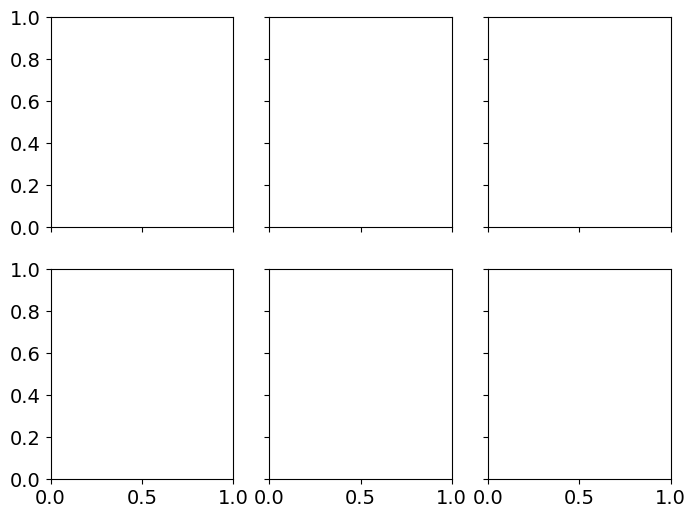

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(8, 6), sharex=True, sharey=True)
for i, dim in enumerate(["1", "2"]):
    for j, method in enumerate(["Single", "Double", "Proj"]):
        rate = (
            fermi_df[f"{method} No Kink ({dim} outer SA)"]
            / fermi_df[f"{method} No Kink ({dim} outer random)"]
        )
        ax = axes[i, j]
        ax.plot(fermi_df[f"{method} No Kink ({dim} outer random)"], label="random")
        ax.plot(fermi_df[f"{method} No Kink ({dim} outer SA)"], label="SA")
        ax.set_title(f"{dim} {method}")
axes[0, 0].legend()

axes[1, 0].set_xlabel("# of threads")
axes[1, 0].set_ylabel("Execution time [ms]")
fig.suptitle("SA / random (SELECT 4 Fermi)", fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
heisenberg_circuit_names, heisenberg_df = load_table(
    "../../out/table/select_4_Heisenberg_time_20250121.txt"
)

In [ ]:
heisenberg_circuit_names

0     4_Heisenberg2D_cylinder_0.5_0.5_0.in 
1     4_Heisenberg2D_cylinder_0.5_0.5_1.in 
2     4_Heisenberg2D_cylinder_0.5_0.5_2.in 
3     4_Heisenberg2D_cylinder_0.5_0.5_3.in 
4     4_Heisenberg2D_cylinder_0.5_0.5_4.in 
5     4_Heisenberg2D_cylinder_0.5_0.5_5.in 
6     4_Heisenberg2D_cylinder_0.5_0.5_6.in 
7       4_Heisenberg2D_cylinder_1_0.5_0.in 
8       4_Heisenberg2D_cylinder_1_0.5_1.in 
9       4_Heisenberg2D_cylinder_1_0.5_2.in 
10      4_Heisenberg2D_cylinder_1_0.5_3.in 
11      4_Heisenberg2D_cylinder_1_0.5_4.in 
12      4_Heisenberg2D_cylinder_1_0.5_5.in 
13      4_Heisenberg2D_cylinder_1_0.5_6.in 
Name: , dtype: object

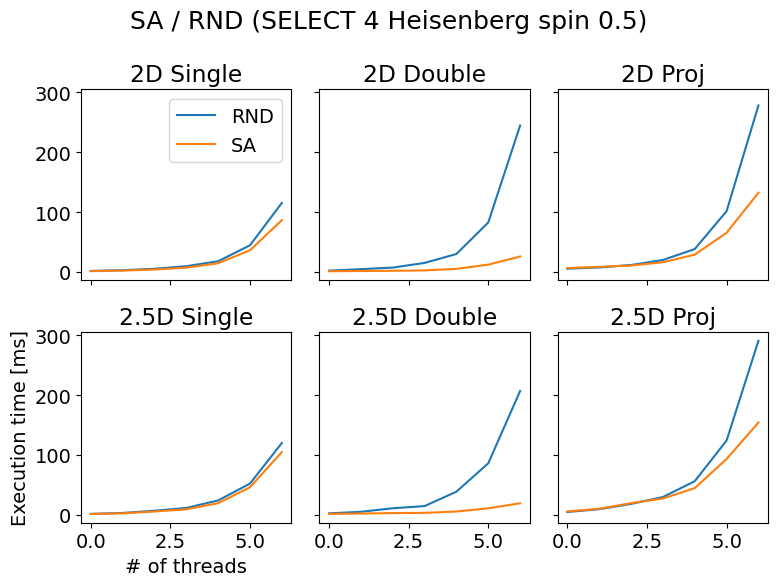

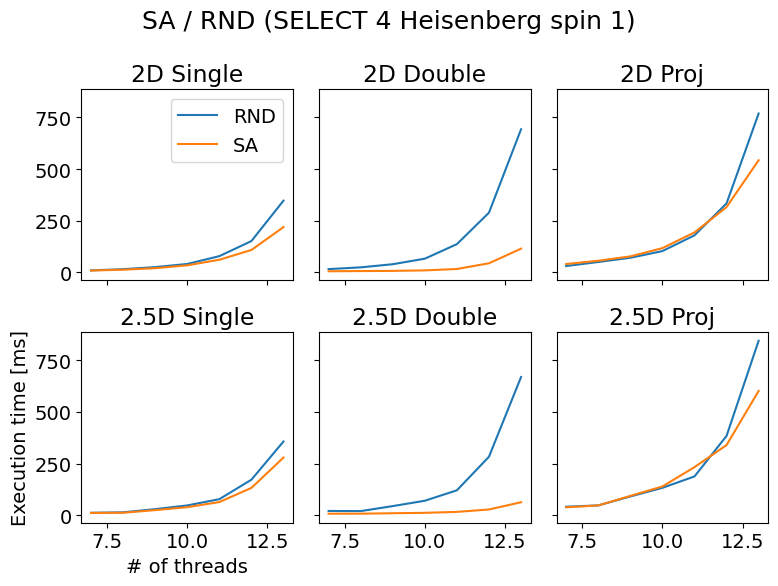

In [ ]:
for name, df_ in zip(
    ["spin 0.5", "spin 1"], [heisenberg_df.iloc[:7], heisenberg_df.iloc[7:]]
):
    fig, axes = plt.subplots(2, 3, figsize=(8, 6), sharex=True, sharey=True)
    for i, dim in enumerate(["2D", "2.5D"]):
        for j, method in enumerate(["Single", "Double", "Proj"]):
            rate = (
                df_[f"{method} No Kink ({dim} SA)"]
                / df_[f"{method} No Kink ({dim} RND)"]
            )
            ax = axes[i, j]
            ax.plot(df_[f"{method} No Kink ({dim} RND)"], label="RND")
            ax.plot(df_[f"{method} No Kink ({dim} SA)"], label="SA")
            ax.set_title(f"{dim} {method}")
    axes[0, 0].legend()

    axes[1, 0].set_xlabel("# of threads")
    axes[1, 0].set_ylabel("Execution time [ms]")
    fig.suptitle(f"SA / RND (SELECT 4 Heisenberg {name})", fontsize=18)
    plt.tight_layout()
    plt.show()